# Complete Code File

## Predicting Weather:

* precipitation
* temperature
* thunder

## Logistic Regression

### Predicting thunder using average wind and precipitation

This model explores the predictability of thunder using precipitation and average wind speed. Our data had thunder as either 1 or NaN, so we decided a logistic regression would best model this concept.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from sklearn import metrics

Read in the data, prepare for model.

In [2]:
# read in data
weather = pd.read_csv("weatherdataCMSE.csv")

In [3]:
# Make all N/A values 0 to use for model
weather = weather.fillna(0)

# check number of instances with thunder (1)
len(weather[weather["WT03"] == 1])  

38

Create training and testing sets with a smaller data set of thunder, with an equal number of thunder instances as no thunder instances. 

In [4]:
# rows with thunder
thunder = weather[weather["WT03"]==1]

# randomly select rows with no thunder
no_thunder = weather[weather["WT03"]==0]
no_thunder = no_thunder.sample(n=38, random_state=2)  #same number of class 0 as class 1

# combine thunder and no thunder to create sample data set
sample_t = pd.concat([thunder, no_thunder])

Make training and testing vectors and labels for the model using wind and precipitation as the features.

In [5]:
# define thunder column as labels (0 or 1), features as our predictors precipitation and wind
labels = sample_t["WT03"]
features = sample_t[["AWND", "PRCP"]]

train_vectors, test_vectors, train_labels, test_labels = train_test_split(
    features,labels, test_size=.25, random_state=6)  # random state for consistent results

Create model, adding a constant to the predictors.

In [6]:
# create model
logit_model = sm.Logit(train_labels, sm.add_constant(train_vectors))

# fit the model
result = logit_model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.505104
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                   WT03   No. Observations:                   57
Model:                          Logit   Df Residuals:                       54
Method:                           MLE   Df Model:                            2
Date:                Sun, 23 Nov 2025   Pseudo R-squ.:                  0.2711
Time:                        20:37:05   Log-Likelihood:                -28.791
converged:                       True   LL-Null:                       -39.501
Covariance Type:            nonrobust   LLR p-value:                 2.233e-05
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.2725      0.907      1.404      0.160      -0.504       3.049
AWND          -0.2955      0.

Find predicted classification, compare to actual classification for accuracy.

In [7]:
predicted = result.predict()

# manually separate predictions into 0 or 1
y_pred = []
for y in predicted:
    if y > .5:
        y = 1
        y_pred.append(y)
    elif y < .5:
        y = 0
        y_pred.append(y)

In [8]:
# compare the predictions to the actual values
metrics.accuracy_score(train_labels, y_pred)

0.7719298245614035

Plot the training data and decision boundary from the model.

NameError: name 'line' is not defined

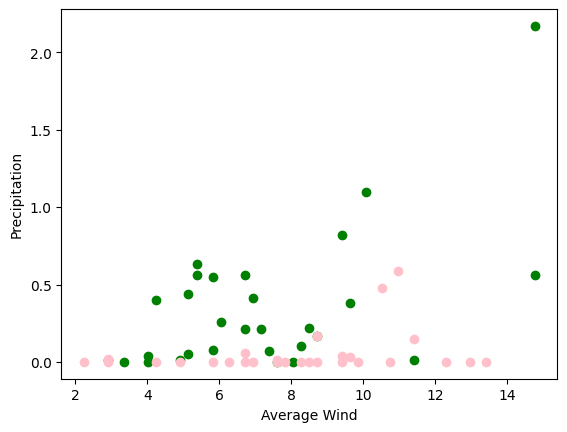

In [9]:
#coefficients
c = result.params.iloc[0]
a1 = result.params.iloc[1]
a2 = result.params.iloc[2]

#x range
x = np.linspace(train_vectors["AWND"].min(), train_vectors["AWND"].max(), 100)

#decision boundary/ classification
# constant + a1(x) + a2(y) = 0
y = (-(c) - (a1*x)) / a2

#scatter plot of data in training vectors, each class plotted separately to label them
plt.scatter(train_vectors["AWND"][train_labels==1], train_vectors["PRCP"][train_labels==1], 
            color="green", label="thunder")
plt.scatter(train_vectors["AWND"][train_labels==0], train_vectors["PRCP"][train_labels==0], 
            color="pink", label="no thunder")
plt.xlabel("Average Wind")
plt.ylabel("Precipitation")
plt.plot(x, line, color='darkred', label="Decision Boundary")
plt.legend()

## Multiple Regression 

In this part of the project, we used multiple regression to explore which variables had significant relationships with different weather outcomes. Instead of only looking at one predictor at a time, multiple regression allowed us to combine several variables and see how they worked together. By testing things like temperature, wind speed, peak gusts, and weather-type indicators, we were able to see which factors actually made a meaningful impact and which ones didn’t. This helped us understand the data better and see how different weather conditions are connected.

### Model 1: Predicting Maximum Temperature Using Wind Speed and Thunder

In [10]:
# Loading the data
df = pd.read_csv("weatherdataCMSE.csv")  

# Selecting variables and dropping missing rows
data = df[['TMAX', 'AWND', 'WT03']].dropna()

# Defining X and y
X = data[['AWND', 'WT03']]   # independent variables
y = data['TMAX']             # dependent variable

# Adding constant term for OLS intercept
X = sm.add_constant(X)

# Fitting the OLS model
model = sm.OLS(y, X).fit()

# Displaying the full statistical report
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   TMAX   R-squared:                       0.491
Model:                            OLS   Adj. R-squared:                  0.476
Method:                 Least Squares   F-statistic:                     34.67
Date:                Sun, 23 Nov 2025   Prob (F-statistic):           9.80e-07
Time:                        20:38:17   Log-Likelihood:                -133.97
No. Observations:                  38   AIC:                             271.9
Df Residuals:                      36   BIC:                             275.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
AWND          -2.6977      0.458     -5.888      0.0

### Model 2: Predicting Precipitation Using Wind Speed and Thunder

In [11]:
# Loading the data
df = pd.read_csv("weatherdataCMSE.csv")  

# Selecting variables and dropping missing rows
data = df[['PRCP', 'AWND', 'WT03']].dropna()

# Define X and y
X = data[['AWND', 'WT03']]   # independent variables
y = data['PRCP']             # dependent variable

# Adding constant term for OLS intercept
X = sm.add_constant(X)

# Fitting the OLS model
model = sm.OLS(y, X).fit()

# Displaying the full statistical report
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   PRCP   R-squared:                       0.294
Model:                            OLS   Adj. R-squared:                  0.274
Method:                 Least Squares   F-statistic:                     14.96
Date:                Sun, 23 Nov 2025   Prob (F-statistic):           0.000442
Time:                        20:38:18   Log-Likelihood:                -13.497
No. Observations:                  38   AIC:                             30.99
Df Residuals:                      36   BIC:                             34.27
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
AWND           0.0744      0.019      3.868      0.0

# Random Forest Model

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# find a model to import (random forest)
from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error, r2_score

In [13]:
weather = pd.read_csv('weatherdataCMSE.csv')
weather = weather.rename(columns={'STATION': 'Station',
                                  'NAME': 'Name',
                                  'DATE': 'Date',
                                  'AWND': 'Avg Wind Speed',
                                  'PGTM': 'Peak Gust Time',
                                  'PRCP': 'Precipitation',
                                  'TAVG': 'Avg Temp',
                                  'TMAX': 'Max Temp',
                                  'TMIN': 'Min Temp',
                                  'WDF2': 'Direction of Fastest 2 Min Wind',
                                  'WDF5': 'Direction of Fastest 5 Sec Wind',
                                  'WSF2': 'Fastest 2 Min Wind Speed',
                                  'WSF5': 'Fastest 5 Sec Wind Speed',
                                  'WT01': 'Fog, Ice Fog, or Freezing Fog',
                                  'WT02': 'Heavy Fog, Heavy Freezing Fog',
                                  'WT03': 'Thunder',
                                  'WT08': 'Smoke or Haze'})
print("Percentage of Data Missing \n------------------------------------------------")
for column in weather.columns:
    missing = weather[column].isnull().sum()
    print(f"{column}: {(missing/len(weather))*100:.3f}%")

print("------------------------------------------------")

# Any columns with more than 5% of data missing can be dropped
columns_to_drop = []
for column in weather.columns:
    missing = weather[column].isnull().sum()
    missing_pct = (missing/len(weather))*100
    if missing_pct > 5:
        columns_to_drop.append(column)
print(f"Columns to drop: {columns_to_drop}")
print("------------------------------------------------")
display(weather.head())

Percentage of Data Missing 
------------------------------------------------
Station: 0.000%
Name: 0.000%
Date: 0.000%
Avg Wind Speed: 1.646%
Peak Gust Time: 1.621%
Precipitation: 0.633%
Avg Temp: 100.000%
Max Temp: 0.101%
Min Temp: 0.101%
Direction of Fastest 2 Min Wind: 1.570%
Direction of Fastest 5 Sec Wind: 1.570%
Fastest 2 Min Wind Speed: 1.570%
Fastest 5 Sec Wind Speed: 1.570%
Fog, Ice Fog, or Freezing Fog: 95.339%
Heavy Fog, Heavy Freezing Fog: 99.544%
Thunder: 99.037%
Smoke or Haze: 96.226%
------------------------------------------------
Columns to drop: ['Avg Temp', 'Fog, Ice Fog, or Freezing Fog', 'Heavy Fog, Heavy Freezing Fog', 'Thunder', 'Smoke or Haze']
------------------------------------------------


,Station,Name,Date,Avg Wind Speed,Peak Gust Time,Precipitation,Avg Temp,Max Temp,Min Temp,Direction of Fastest 2 Min Wind,Direction of Fastest 5 Sec Wind,Fastest 2 Min Wind Speed,Fastest 5 Sec Wind Speed,"Fog, Ice Fog, or Freezing Fog","Heavy Fog, Heavy Freezing Fog",Thunder,Smoke or Haze
0,USW00014822,"DETROIT CITY AIRPORT, MI US",2015-01-01,16.33,941.0,0.00,NaN,33.0,19.0,240.0,230.0,23.9,31.1,NaN,NaN,NaN,NaN
1,USW00014822,"DETROIT CITY AIRPORT, MI US",2015-01-02,6.71,1323.0,0.00,NaN,36.0,27.0,260.0,250.0,16.1,23.0,NaN,NaN,NaN,NaN
2,USW00014822,"DETROIT CITY AIRPORT, MI US",2015-01-03,6.71,1221.0,0.38,NaN,37.0,26.0,110.0,110.0,16.1,21.0,NaN,NaN,NaN,NaN
3,USW00014822,"DETROIT CITY AIRPORT, MI US",2015-01-04,9.84,2304.0,0.07,NaN,38.0,21.0,300.0,290.0,23.9,33.1,NaN,NaN,NaN,NaN
4,USW00014822,"DETROIT CITY AIRPORT, MI US",2015-01-05,13.20,445.0,0.00,NaN,21.0,8.0,310.0,320.0,23.0,36.9,NaN,NaN,NaN,NaN


In [14]:
# Drop bad columns
weather = weather.drop(columns_to_drop, axis=1)
weather = weather.drop(['Name', 'Station'], axis=1)
weather = weather.dropna()

In [15]:
# Columns to add: 
# Did it rain the day before?
# Mean temperature (max temp - min temp / 2)
# Temperature range (max temp - min temp) aka "diurnal_range"

shifted_precip = weather['Precipitation'].shift(1)
precip_yesterday_bool = shifted_precip > 0
weather['Precipitation Yesterday'] = precip_yesterday_bool.astype(int)

weather['Mean Temp'] = (weather['Max Temp'] + weather['Min Temp']) / 2
weather['Diurnal Temp'] = weather['Max Temp'] - weather['Min Temp']

# Turn date into datetime object
weather['Date'] = pd.to_datetime(weather['Date'])

weather['Year'] = weather['Date'].dt.year
weather['Month'] = weather['Date'].dt.month
weather['Day'] = weather['Date'].dt.day
weather = weather.drop(columns=['Date'])

display(weather[['Precipitation', 'Precipitation Yesterday', 'Mean Temp', 'Diurnal Temp', 'Year', 'Month', 'Day']].head(10))

,Precipitation,Precipitation Yesterday,Mean Temp,Diurnal Temp,Year,Month,Day
0,0.00,0,26.0,14.0,2015,1,1
1,0.00,0,31.5,9.0,2015,1,2
2,0.38,0,31.5,11.0,2015,1,3
3,0.07,1,29.5,17.0,2015,1,4
4,0.00,1,14.5,13.0,2015,1,5
5,0.00,0,14.0,10.0,2015,1,6
6,0.01,0,12.0,12.0,2015,1,7
7,0.00,1,8.5,15.0,2015,1,8
8,0.00,0,12.5,13.0,2015,1,9
9,0.00,0,10.0,16.0,2015,1,10


In [16]:
features = weather.drop('Precipitation', axis=1).columns
X = weather[features]
y = weather['Precipitation']


train_X, test_X, train_y, test_y = train_test_split(
    X, y, 
    test_size=0.2,     
    random_state=42
)

print("TRAIN SHAPE:", train_X.shape, train_y.shape)
print("TEST SHAPE:", test_X.shape, test_y.shape)

TRAIN SHAPE: (3084, 14) (3084,)
TEST SHAPE: (772, 14) (772,)


In [17]:
forest_model = RandomForestRegressor(random_state=42)

forest_model.fit(train_X, train_y)

preds = forest_model.predict(test_X)

val_mae = mean_absolute_error(test_y, preds)

val_mae


0.10971295336787563

In [18]:
mae = mean_absolute_error(y_true=test_y, y_pred=preds)
mse = mean_squared_error(y_true=test_y, y_pred=preds)
me  = np.mean(test_y - preds)

print(f"Mean Absolute Error Score: {mae:.3f}")
print(f"ME   (bias): {me:.3f}")
print(f"RMSE: {np.sqrt(mse):.3f}")
print(f"MSE: {mse:.3f}")

Mean Absolute Error Score: 0.110
ME   (bias): -0.006
RMSE: 0.230
MSE: 0.053
